In [ ]:
pip install tensorflow-text

In [ ]:
pip install sentencepiece

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import tensorflow as tf
import tensorflow_text as tf_text
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns  # Import seaborn for visualization

device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))


Found GPU at: /device:GPU:0


In [ ]:
!pip install transformers

In [ ]:
from transformers import ElectraTokenizer, ElectraForSequenceClassification
import torch # Import torch library
from torch.optim import AdamW # Import AdamW from torch.optim

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from keras.utils import pad_sequences
from sklearn.model_selection import train_test_split


from transformers import ElectraTokenizer, ElectraModel, ElectraForSequenceClassification


from tqdm import tqdm, trange
import pandas as pd
import io
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpu = torch.cuda.device_count()
torch.cuda.get_device_name(0)

'Tesla T4'

In [ ]:
df = pd.read_csv("/content/Dataset Cyberbullying Media Sosial.csv")

In [ ]:
df

,Text,Label,CaseFold,RegRemoval,SymbolsRemoval
0,Oooo statusnya masih darurat tho?... Daruratny...,0,oooo statusnya masih darurat tho?... daruratny...,oooo statusnya masih darurat tho?... daruratny...,oooo statusnya masih darurat tho?... daruratny...
1,Pembicaraan antar profesor pas mengemukakan pe...,1,pembicaraan antar profesor pas mengemukakan pe...,pembicaraan antar profesor pas mengemukakan pe...,pembicaraan antar profesor pas mengemukakan pe...
2,nonton cuma liat timecode berjalan...soalnya k...,1,nonton cuma liat timecode berjalan...soalnya k...,nonton cuma liat timecode berjalan...soalnya k...,nonton cuma liat timecode berjalan...soalnya k...
3,Kura kura Galapagos dan ikan laut dalam palung...,1,kura kura galapagos dan ikan laut dalam palung...,kura kura galapagos dan ikan laut dalam palung...,kura kura galapagos dan ikan laut dalam palung...
4,Podcast 3 makhluk ghoib.,1,podcast 3 makhluk ghoib.,podcast makhluk ghoib.,podcast makhluk ghoib.
...,...,...,...,...,...
66630,Istinysaq (Memasukkan air dalam hidung) serta ...,0,istinysaq (memasukkan air dalam hidung) serta ...,istinysaq (memasukkan air dalam hidung) serta ...,istinysaq (memasukkan air dalam hidung) serta ...
66631,Istinysaq (Memasukkan air dalam hidung) serta ...,0,istinysaq (memasukkan air dalam hidung) serta ...,istinysaq (memasukkan air dalam hidung) serta ...,istinysaq (memasukkan air dalam hidung) serta ...
66632,Repost @kompascom (Berita selengkapnya klik IG...,0,repost @kompascom (berita selengkapnya klik ig...,repost @kompascom (berita selengkapnya klik ig...,repost @kompascom (berita selengkapnya klik ig...
66633,jasaakuntansi.pajak Menyediakan jasa pengerjaa...,0,jasaakuntansi.pajak menyediakan jasa pengerjaa...,jasaakuntansi.pajak menyediakan jasa pengerjaa...,jasaakuntansi.pajak menyediakan jasa pengerjaa...


In [ ]:
df.drop(["CaseFold", "RegRemoval", "SymbolsRemoval"],axis=1,inplace=True)

In [ ]:
df

,Text,Label
0,Oooo statusnya masih darurat tho?... Daruratny...,0
1,Pembicaraan antar profesor pas mengemukakan pe...,1
2,nonton cuma liat timecode berjalan...soalnya k...,1
3,Kura kura Galapagos dan ikan laut dalam palung...,1
4,Podcast 3 makhluk ghoib.,1
...,...,...
66630,Istinysaq (Memasukkan air dalam hidung) serta ...,0
66631,Istinysaq (Memasukkan air dalam hidung) serta ...,0
66632,Repost @kompascom (Berita selengkapnya klik IG...,0
66633,jasaakuntansi.pajak Menyediakan jasa pengerjaa...,0


In [ ]:
df.isna().sum()

,0
Text,0
Label,0


In [ ]:
df['Text'] = df['Text'].str.replace('[^a-zA-Z0-9\s]+', '', regex=True)
df

,Text,Label
0,Oooo statusnya masih darurat tho Daruratnya di...,0
1,Pembicaraan antar profesor pas mengemukakan pe...,1
2,nonton cuma liat timecode berjalansoalnya kaga...,1
3,Kura kura Galapagos dan ikan laut dalam palung...,1
4,Podcast 3 makhluk ghoib,1
...,...,...
66630,Istinysaq Memasukkan air dalam hidung serta Is...,0
66631,Istinysaq Memasukkan air dalam hidung serta Is...,0
66632,Repost kompascom Berita selengkapnya klik IG S...,0
66633,jasaakuntansipajak Menyediakan jasa pengerjaan...,0


In [ ]:
labels = df['Label']
unique_labels = labels.unique()
unique_labels

array([0, 1])

In [ ]:
df['Label'].value_counts()

,count
Label,
0,60487
1,6148


In [ ]:
# Menggabungkan teks dan label untuk mempermudah pengolahan
data = pd.DataFrame({'Text': df['Text'], 'Label': labels})

# Memisahkan data berdasarkan label
label_0 = data[data['Label'] == 0]
label_1 = data[data['Label'] == 1]

# Undersampling ke ukuran yang sama
from sklearn.utils import resample # Import resample if it's not already imported

# Menentukan ukuran terkecil
min_size = min(len(label_0), len(label_1))

# Melakukan undersampling pada label mayoritas
label_0_undersampled = resample(label_0,
                                 replace=False, # Without replacement (no duplicates)
                                 n_samples=min_size, # Match the minority class size
                                 random_state=42) # For reproducibility

# Gabungkan kembali data yang telah di-undersample
undersampled_data = pd.concat([label_0_undersampled, label_1])

# Perbarui df dengan data yang telah di-undersample
df = undersampled_data.copy()

In [ ]:
df['Label'].value_counts()

,count
Label,
0,6148
1,6148


In [ ]:
df

,Text,Label
26489,Bucin,0
15811,Salute buat Deny cagur kuat banget,0
6602,Cheewyxizy iyaa kaka sayang semua boleh komen ...,0
32938,Fajar lu di kasih tisu itu buat lap air mata l...,0
36625,Kayanya dia butuh psikolog,0
...,...,...
66538,Ada yang kena omel TKW Indonesia nih Mbak TKW ...,1
66590,Coba makanya deh itu pegawai bea cukai produc...,1
66592,Indonesia urutan ke berapa ya Hi Monefriends...,1
66594,Rubicon nya siapa nih Lebih kaget lagi kalo li...,1


In [ ]:
import re
import string
def clean_text(text):
#    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
#    and remove words containing numbers.'''
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

In [ ]:
df['text_clean'] = df['Text'].apply(clean_text)
df.sample(10)

,Text,Label,text_clean
46808,Kang undang balik tapi ajak vicky kang wah ram...,0,kang undang balik tapi ajak vicky kang wah ram...
3997,Biasa untuk org yg omong besar mulut besar ker...,1,biasa untuk org yg omong besar mulut besar ker...
14435,Yg belum pernah punya anak emg belum tau kl ad...,0,yg belum pernah punya anak emg belum tau kl ad...
65749,Bayar pajak buat yaaa terus Yaaa buaaattt RT A...,1,bayar pajak buat yaaa terus yaaa buaaattt rt a...
1422,Bang coki sang strongman dan paman cokay alsha...,1,bang coki sang strongman dan paman cokay alsha...
34033,Salut buat bang Deni ga tertawa,0,salut buat bang deni ga tertawa
4932,Kalau tvone ingin membantu masyarakat memilih ...,1,kalau tvone ingin membantu masyarakat memilih ...
3943,Lah itu yg ngacir ke Australia yg plumpang keb...,1,lah itu yg ngacir ke australia yg plumpang keb...
34900,Mau nnya bang lu nahan ketawa gak sih bang dan...,0,mau nnya bang lu nahan ketawa gak sih bang dan...
4637,Itu menurut kaum PDI aja yg panik,1,itu menurut kaum pdi aja yg panik


In [ ]:
# STOPWORDS
import nltk
#nltk.download('stopwords')
#stop_words = stopwords.words('english')
#more_stopwords = ['u', 'im', 'c']
#stop_words = stop_words + more_stopwords

#def remove_stopwords(text):
#    text = ' '.join(word for word in text.split(' ') if word not in stop_words)
#    return text

#df['text_clean'] = df['text_clean'].apply(remove_stopwords)
#df.head()

In [ ]:
#STEMMING
#stemmer = nltk.SnowballStemmer("english")

#def stemm_text(text):
#    text = ' '.join(stemmer.stem(word) for word in text.split(' '))
#    return text

#df['text_clean'] = df['text_clean'].apply(stemm_text)
#df.head()

In [ ]:
df

,Text,Label,text_clean
26489,Bucin,0,bucin
15811,Salute buat Deny cagur kuat banget,0,salute buat deny cagur kuat banget
6602,Cheewyxizy iyaa kaka sayang semua boleh komen ...,0,cheewyxizy iyaa kaka sayang semua boleh komen ...
32938,Fajar lu di kasih tisu itu buat lap air mata l...,0,fajar lu di kasih tisu itu buat lap air mata l...
36625,Kayanya dia butuh psikolog,0,kayanya dia butuh psikolog
...,...,...,...
66538,Ada yang kena omel TKW Indonesia nih Mbak TKW ...,1,ada yang kena omel tkw indonesia nih mbak tkw ...
66590,Coba makanya deh itu pegawai bea cukai produc...,1,coba makanya deh itu pegawai bea cukai produc...
66592,Indonesia urutan ke berapa ya Hi Monefriends...,1,indonesia urutan ke berapa ya hi monefriends...
66594,Rubicon nya siapa nih Lebih kaget lagi kalo li...,1,rubicon nya siapa nih lebih kaget lagi kalo li...


In [ ]:
text = df.Text.values
label = df.Label.values

In [ ]:
text = [text_clean + " [SEP] [CLS]" for text_clean in text]
label = df.Label.values

In [ ]:
text

['Bucin [SEP] [CLS]',
 'Salute buat Deny cagur kuat banget  [SEP] [CLS]',
 'Cheewyxizy iyaa kaka sayang semua boleh komen makanya saya bilang hati hati dan kalo perlu ga usah dibalesin Soalnya saya kasian entar ka gita makin di rundung lg krn tanpa masalah ini pun beliau sudah sering di rundung apalagi netizen jempol laknat ada dimana mana [SEP] [CLS]',
 'Fajar lu di kasih tisu itu buat lap air mata lu bukan lap kuping sama rambut [SEP] [CLS]',
 'Kayanya dia butuh psikolog [SEP] [CLS]',
 'HAhahaha [SEP] [CLS]',
 'Pinter juga lho fajar bikin pantunkereennnsalut fajarSemangat Fajar  [SEP] [CLS]',
 'Baru kali ini liat Dustin paling waras  [SEP] [CLS]',
 'Lagi cari momen sodara kandung fajar [SEP] [CLS]',
 'Andai abang adik Mirip banget mas anji sm fajar mukanya [SEP] [CLS]',
 'Kok bisa  ya fajar ngapalain segitu banyak quotes [SEP] [CLS]',
 'Sangat Setuju dengan Formasi GANJAR P  PRABOWO S [SEP] [CLS]',
 'Pengen liat ntar 5th kedepan klo dia liat video ini MALU GA YAAA  [SEP] [CLS]',
 'Ke

In [ ]:
#tweet = pd.DataFrame(tweet)

In [ ]:
#tweet.to_csv('tweet.csv')

In [ ]:
tokenizer = ElectraTokenizer.from_pretrained('google/electra-base-discriminator')
model = ElectraForSequenceClassification.from_pretrained('google/electra-base-discriminator', num_labels=2)
model.cuda()

tokenized_text = [tokenizer.tokenize(sent) for sent in text]
print ("Tokenize the first sentence:")
print (tokenized_text)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Tokenize the first sentence:
[['bu', '##cin', '[SEP]', '[CLS]'], ['salute', 'bu', '##at', 'deny', 'ca', '##gur', 'ku', '##at', 'bang', '##et', '[SEP]', '[CLS]'], ['che', '##ew', '##yx', '##iz', '##y', 'i', '##ya', '##a', 'ka', '##ka', 'say', '##ang', 'se', '##mu', '##a', 'bo', '##le', '##h', 'ko', '##men', 'ma', '##kan', '##ya', 'say', '##a', 'bi', '##lang', 'hat', '##i', 'hat', '##i', 'dan', 'ka', '##lo', 'per', '##lu', 'ga', 'usa', '##h', 'di', '##bal', '##es', '##in', 'so', '##al', '##nya', 'say', '##a', 'ka', '##sian', 'en', '##tar', 'ka', 'gi', '##ta', 'ma', '##kin', 'di', 'run', '##dun', '##g', 'l', '##g', 'k', '##rn', 'tan', '##pa', 'mas', '##ala', '##h', 'in', '##i', 'pun', 'bel', '##ia', '##u', 'sud', '##ah', 'ser', '##ing', 'di', 'run', '##dun', '##g', 'ap', '##ala', '##gi', 'net', '##ize', '##n', 'jem', '##pol', 'la', '##k', '##nat', 'ada', 'dim', '##ana', 'mana', '[SEP]', '[CLS]'], ['fa', '##jar', 'lu', 'di', 'ka', '##si', '##h', 'tis', '##u', 'it', '##u', 'bu', '##at', 'la

In [ ]:
#tokenized_tweet = pd.DataFrame(tokenized_tweet)
#tokenized_tweet.to_csv('token.csv')

In [ ]:
MAX_LEN = 200

In [ ]:
# Use the ELECTRA tokenizer to convert the tokens to their index numbers in the ELECTRA vocabulary
input_ids_text = [tokenizer.convert_tokens_to_ids(x) for x in tokenized_text]

In [ ]:
# Pad our input tokens
input_ids_text = pad_sequences(input_ids_text, maxlen=MAX_LEN, dtype="long", truncating="post", padding="post")

In [ ]:
#embeddings_dictionary = dict()
#embedding_dim = 100

#embedding_matrix = np.zeros((vocab_length, embedding_dim))

#for word, index in word_tokenizer.word_index.items():
#    embedding_vector = embeddings_dictionary.get(word)
#    if embedding_vector is not None:
#        embedding_matrix[index] = embedding_vector

#embedding_matrix

In [ ]:
from os.path import join

In [ ]:
input_ids_text.shape

(12296, 200)

In [ ]:
#input_ids_tweet.dtype()

In [ ]:
#input = input_ids_tweet.tolist()

In [ ]:
#input = ' '.join([str(elem) for elem in input_ids_tweet])

In [ ]:
#input.type()

In [ ]:
#input = pd.DataFrame(input)

In [ ]:
#input = input.apply(str)

In [ ]:
#input=[input]

In [ ]:
#input.shape

In [ ]:
#feature.shape

In [ ]:
#df = pd.DataFrame(feature)
#df

In [ ]:
# Create attention masks
attention_masks = []

tokenized_text = [tokenizer.tokenize(sent) for sent in text]
input_ids_text = [tokenizer.convert_tokens_to_ids(x) for x in tokenized_text]
input_ids_text = pad_sequences(input_ids_text, maxlen=MAX_LEN, dtype="long", truncating="post", padding="post")
attention_masks = [[float(i>0) for i in seq] for seq in input_ids_text]

In [ ]:
Label = df['Label']

In [ ]:
# Use train_test_split to split our data into train and validation sets for training

train_inputs_text, validation_inputs_text, train_labels_Label, validation_labels_Label = train_test_split(input_ids_text, Label,
                                                            random_state=2018, test_size=0.2)
train_masks, validation_masks, _, _ = train_test_split(attention_masks,input_ids_text,
                                             random_state=2018, test_size=0.2)

In [ ]:
train_labels_int = train_labels_Label.astype(int)
validation_labels_int = validation_labels_Label.astype(int)

In [ ]:
# Convert all of our data into torch tensors, the required datatype for our model

train_inputs_text = torch.tensor(train_inputs_text)
validation_inputs_text = torch.tensor(validation_inputs_text)
train_labels_int = torch.tensor(train_labels_int.values) # Convert Series to NumPy array
validation_labels_int = torch.tensor(validation_labels_int.values) # Convert Series to NumPy array
train_masks = torch.tensor(train_masks)
validation_masks = torch.tensor(validation_masks)

In [ ]:
#train_masks = torch.tensor(train_masks)
#validation_masks = torch.tensor(validation_masks)

In [ ]:
# Select a batch size for training. For fine-tuning with XLNet, the authors recommend a batch size of 32, 48, or 128. We will use 32 here to avoid memory issues.
batch_size = 64

# Create an iterator of our data with torch DataLoader. This helps save on memory during training because, unlike a for loop,
# with an iterator the entire dataset does not need to be loaded into memory

train_data = TensorDataset(train_inputs_text, train_masks, train_labels_int)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

validation_data = TensorDataset(validation_inputs_text, validation_masks, validation_labels_int)
validation_sampler = SequentialSampler(validation_data)
validation_dataloader = DataLoader(validation_data, sampler=validation_sampler, batch_size=batch_size)

In [ ]:
# Load ELECTRAForSequenceClassification, the pretrained ELECTRA model with a single linear classification layer on top.

model = ElectraForSequenceClassification.from_pretrained("google/electra-base-discriminator", num_labels=2)
model.cuda()

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ElectraForSequenceClassification(
  (electra): ElectraModel(
    (embeddings): ElectraEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): ElectraEncoder(
      (layer): ModuleList(
        (0-11): 12 x ElectraLayer(
          (attention): ElectraAttention(
            (self): ElectraSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ElectraSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): L

In [ ]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("No GPU available, using CPU instead.")

Using GPU: Tesla T4


In [ ]:
param_optimizer = list(model.named_parameters())
no_decay = ['bias', 'gamma', 'beta']
optimizer_grouped_parameters = [
    {'params': [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)],
     'weight_decay_rate': 0.0001},
    {'params': [p for n, p in param_optimizer if any(nd in n for nd in no_decay)],
     'weight_decay_rate': 0.0}
]

In [ ]:
# This variable contains all of the hyperparemeter information our training loop needs
optimizer = AdamW(optimizer_grouped_parameters,
                     lr=2e-5)

In [ ]:
# Function to calculate the accuracy of our predictions vs labels
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Train loss: 0.6418957706395682
Testing Accuracy: 0.6919642857142857
Accuracy: 0.6926829268292682
Precision: 0.6598951507208388
Recall: 0.8094855305466238
F1-Score: 0.7270758122743682


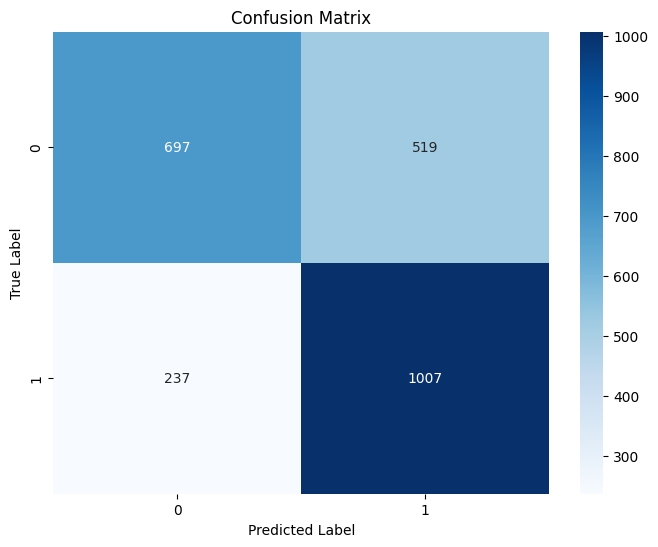

Epoch:  10%|█         | 1/10 [05:37<50:41, 337.91s/it]

Saved the best model with Testing accuracy: 0.6919642857142857
Train loss: 0.5531414362130227
Testing Accuracy: 0.7439903846153846
Accuracy: 0.7439024390243902
Precision: 0.7274074074074074
Recall: 0.7893890675241158
F1-Score: 0.7571318427139553


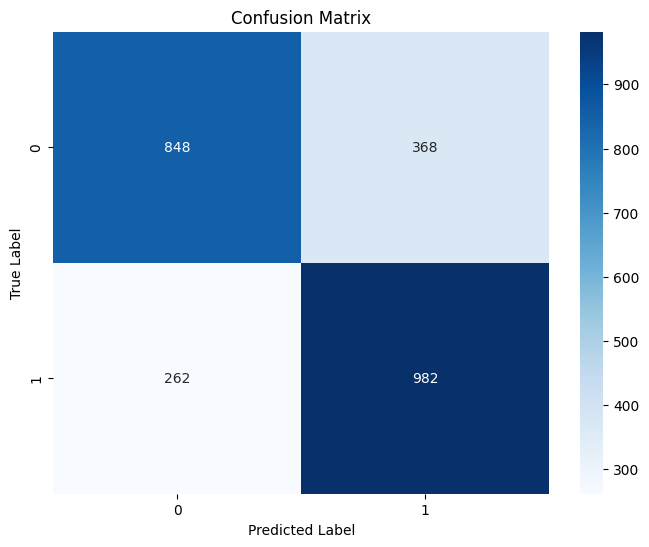

Epoch:  20%|██        | 2/10 [11:15<45:01, 337.71s/it]

Saved the best model with Testing accuracy: 0.7439903846153846
Train loss: 0.47529205737949964
Testing Accuracy: 0.753834706959707
Accuracy: 0.7528455284552845
Precision: 0.7544
Recall: 0.7580385852090032
F1-Score: 0.756214915797915


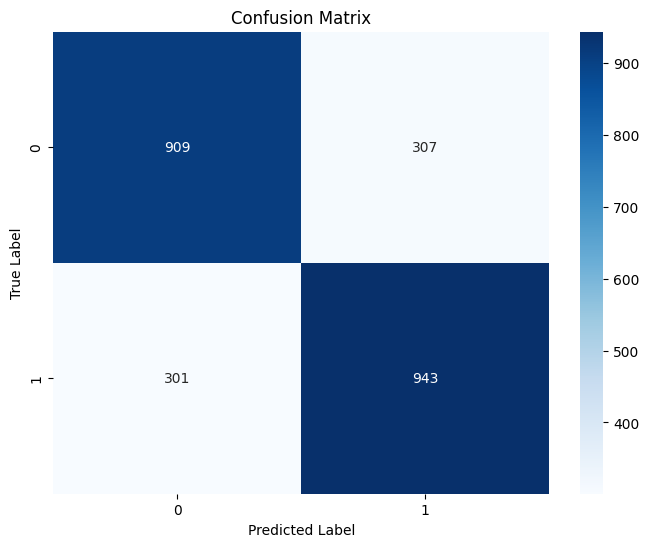

Epoch:  30%|███       | 3/10 [16:52<39:20, 337.21s/it]

Saved the best model with Testing accuracy: 0.753834706959707
Train loss: 0.41448659382083197
Testing Accuracy: 0.7493131868131868
Accuracy: 0.748780487804878
Precision: 0.717966573816156
Recall: 0.8287781350482315
F1-Score: 0.7694029850746269


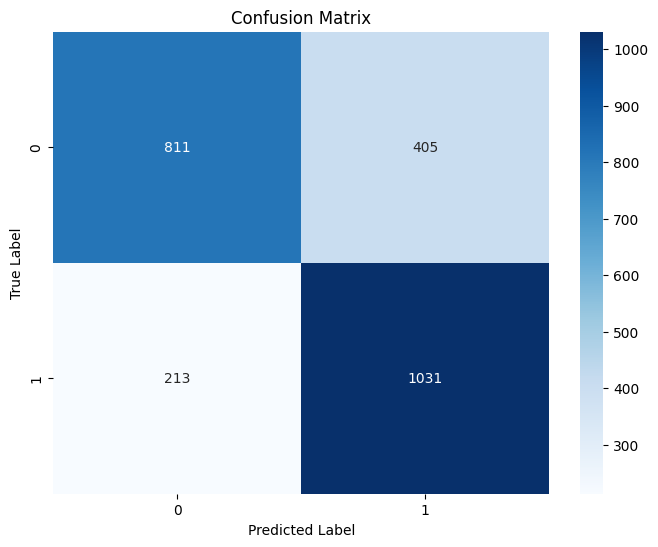

Epoch:  40%|████      | 4/10 [22:22<33:26, 334.42s/it]

Train loss: 0.34499638653420783
Testing Accuracy: 0.7578411172161172
Accuracy: 0.7569105691056911
Precision: 0.7709731543624161
Recall: 0.7387459807073955
F1-Score: 0.7545155993431856


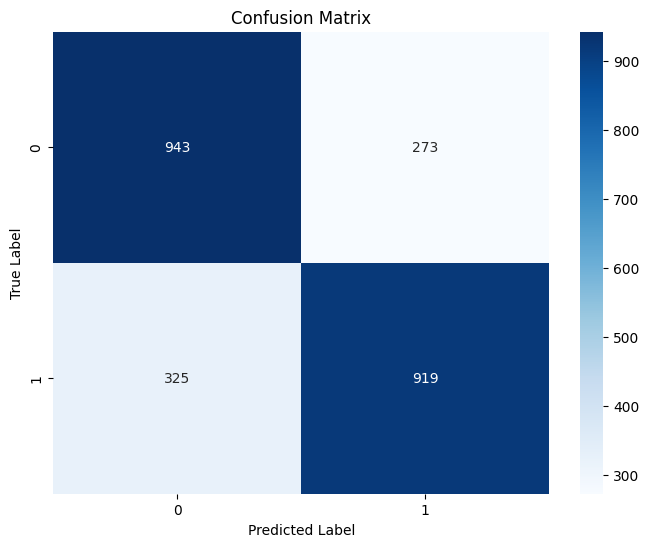

Epoch:  50%|█████     | 5/10 [27:57<27:54, 334.85s/it]

Saved the best model with Testing accuracy: 0.7578411172161172
Train loss: 0.2949767355601509
Testing Accuracy: 0.7560096153846154
Accuracy: 0.7560975609756098
Precision: 0.7473118279569892
Recall: 0.7821543408360129
F1-Score: 0.7643362136684996


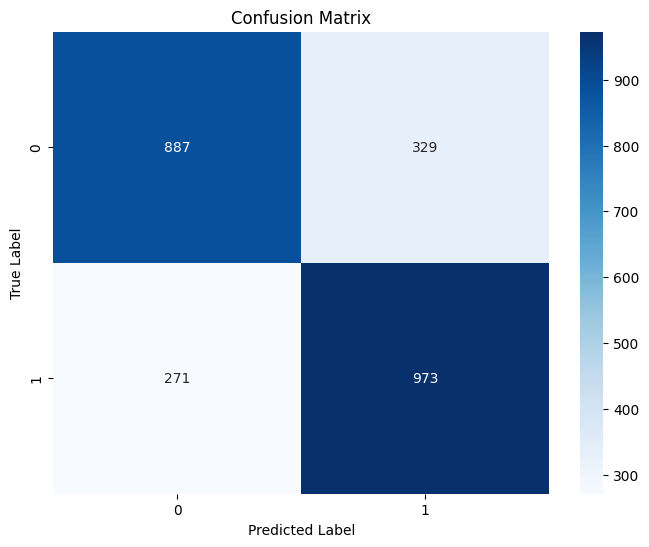

Epoch:  60%|██████    | 6/10 [33:28<22:13, 333.27s/it]

Train loss: 0.24037717950421494
Testing Accuracy: 0.7442765567765568
Accuracy: 0.7447154471544716
Precision: 0.6961783439490445
Recall: 0.8786173633440515
F1-Score: 0.7768301350390903


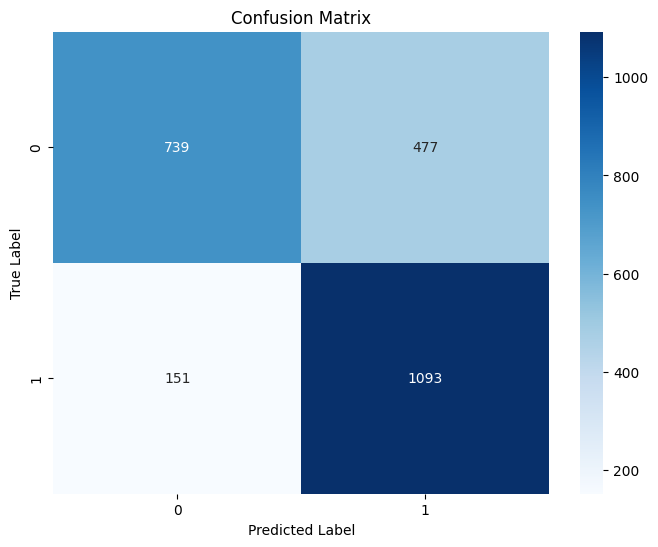

Epoch:  70%|███████   | 7/10 [38:58<16:37, 332.36s/it]

Train loss: 0.20630045965700955
Testing Accuracy: 0.7549221611721612
Accuracy: 0.7544715447154472
Precision: 0.7836879432624113
Recall: 0.7106109324758842
F1-Score: 0.7453625632377741


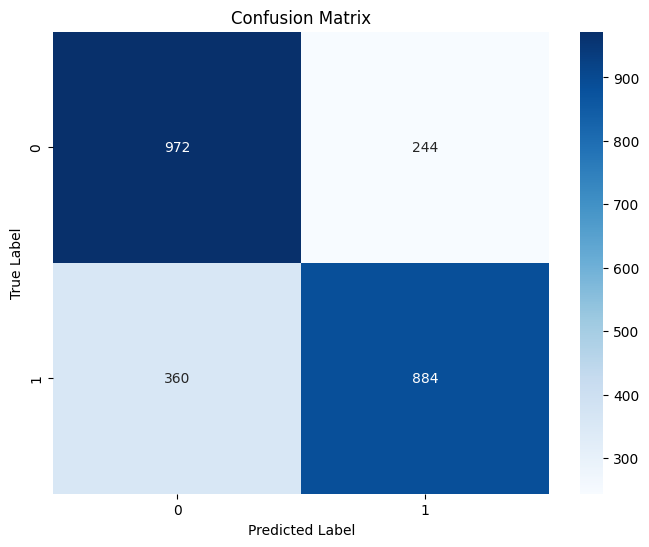

Epoch:  70%|███████   | 7/10 [44:29<19:03, 381.29s/it]

Early stopping! No improvement for 3 consecutive epochs.


In [ ]:
# Store our loss and accuracy for plotting
train_loss_set = []

# Number of training epochs (authors recommend between 2 and 4)
epochs = 10

# Directory to save the best model
save_dir = "/content/drive/MyDrive/ElectraFix/Model"

best_epoch = 0
best_cm = None

os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "text_model.pth")

# Initialize early stopping parameters
best_eval_accuracy = 0.0
patience = 3  # Number of epochs with no improvement after which training will be stopped
early_stopping_counter = 0

# List untuk menyimpan metrik evaluasi setiap epoch
epoch_accuracy = []
epoch_precision = []
epoch_recall = []
epoch_f1 = []

# trange is a tqdm wrapper around the normal python range
for _ in trange(epochs, desc="Epoch"):

  # Training

  # Set our model to training mode (as opposed to evaluation mode)
  model.train()

  # Tracking variables
  tr_loss = 0
  nb_tr_examples, nb_tr_steps = 0, 0

  # Train the data for one epoch
  for step, batch in enumerate(train_dataloader):
    # Add batch to GPU
    batch = tuple(t.to(device) for t in batch)
    # Unpack the inputs from our dataloader
    b_input_ids, b_input_mask, b_labels = batch
    # Clear out the gradients (by default they accumulate)
    optimizer.zero_grad()
    # Forward pass
    outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
    loss = outputs[0]
    logits = outputs[1]
    train_loss_set.append(loss.item())
    # Backward pass
    loss.backward()
    # Update parameters and take a step using the computed gradient
    optimizer.step()


    # Update tracking variables
    tr_loss += loss.item()
    nb_tr_examples += b_input_ids.size(0)
    nb_tr_steps += 1

  print("Train loss: {}".format(tr_loss/nb_tr_steps))


  # Validation

  # Put model in evaluation mode to evaluate loss on the validation set
  model.eval()

  # Tracking variables
  eval_loss, eval_accuracy = 0, 0
  nb_eval_steps, nb_eval_examples = 0, 0

  # Store all labels and predictions for this epoch
  all_labels = []
  all_confusion_matrices = []
  epoch_predictions = []


  # Evaluate data for one epoch
  for batch in validation_dataloader:
    # Add batch to GPU
    batch = tuple(t.to(device) for t in batch)
    # Unpack the inputs from our dataloader
    b_input_ids, b_input_mask, b_labels = batch
    # Telling the model not to compute or store gradients, saving memory and speeding up validation
    with torch.no_grad():
      # Forward pass, calculate logit predictions
      output = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)
      logits = output[0]

    # Move logits and labels to CPU
    logits = logits.detach().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()

    # Store predictions and true labels
    predictions = np.argmax(logits, axis=1).flatten()  # Get predicted labels
    epoch_predictions.extend(predictions)  # <--- Change: Append to epoch_predictions
    all_labels.extend(label_ids)  # True labels

    tmp_eval_accuracy = flat_accuracy(logits, label_ids)

    eval_accuracy += tmp_eval_accuracy
    nb_eval_steps += 1

  print("Testing Accuracy: {}".format(eval_accuracy/nb_eval_steps))

  current_eval_accuracy = eval_accuracy / nb_eval_steps

  # Calculate and store evaluation metrics for the entire epoch (outside the batch loop)
  from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
  accuracy = accuracy_score(all_labels, epoch_predictions)
  precision = precision_score(all_labels, epoch_predictions)
  recall = recall_score(all_labels, epoch_predictions)
  f1 = 2 * (precision * recall) / (precision + recall)


  epoch_accuracy.append(accuracy)
  epoch_precision.append(precision)
  epoch_recall.append(recall)
  epoch_f1.append(f1)

  print("Accuracy: {}".format(accuracy))  # Tampilkan akurasi epoch ini
  print("Precision: {}".format(precision))  # Tampilkan presisi epoch ini
  print("Recall: {}".format(recall))  # Tampilkan recall epoch ini
  print("F1-Score: {}".format(f1))  # Tampilkan F1-score epoch ini

  # Calculate confusion matrix
  cm = confusion_matrix(all_labels, epoch_predictions)

  # Simpan confusion matrix
  all_confusion_matrices.append(cm)

  # Display confusion matrix using seaborn heatmap
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
              xticklabels=[0, 1], yticklabels=[0, 1])  # Customize labels if needed
  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")
  plt.title("Confusion Matrix")
  plt.show()

  # Check for early stopping
  if current_eval_accuracy > best_eval_accuracy:
      best_eval_accuracy = current_eval_accuracy
      early_stopping_counter = 0
      best_epoch = _ + 1
      best_cm = cm

      # Save the best model
      torch.save(model.state_dict(), best_model_path)
      print(f"Saved the best model with Testing accuracy: {best_eval_accuracy}")
  else:
      early_stopping_counter += 1

  if early_stopping_counter >= patience:
      print(f"Early stopping! No improvement for {patience} consecutive epochs.")
      break  # Stop training


Hasil Evaluasi (Epoch Terbaik):
     Metrik     Nilai  Epoch Terbaik
0   Akurasi  0.756911              5
1   Presisi  0.770973              5
2    Recall  0.738746              5
3  F1-Score  0.754516              5


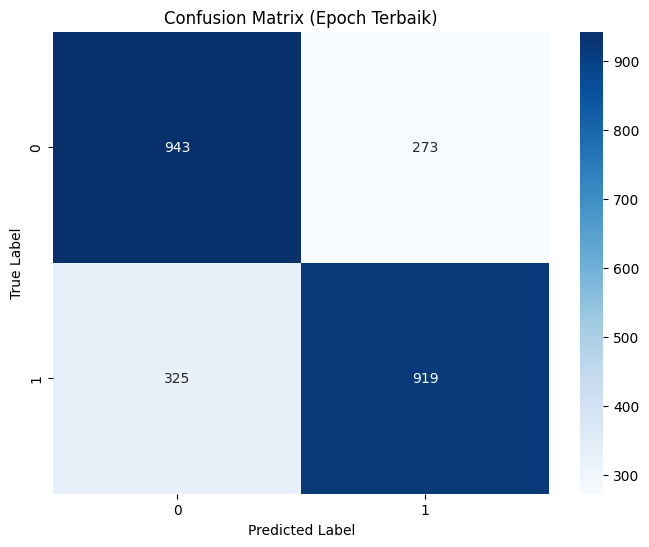

In [ ]:
data = {'Metrik': ['Akurasi', 'Presisi', 'Recall', 'F1-Score'],
        'Nilai': [epoch_accuracy[best_epoch - 1], epoch_precision[best_epoch - 1], epoch_recall[best_epoch - 1], epoch_f1[best_epoch - 1]],
        'Epoch Terbaik': [best_epoch, best_epoch, best_epoch, best_epoch]}
df_evaluasi = pd.DataFrame(data)
print("\nHasil Evaluasi (Epoch Terbaik):")
print(df_evaluasi)


# Access the confusion matrix using the valid index
best_cm

plt.figure(figsize=(8, 6))
sns.heatmap(best_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Epoch Terbaik)")
plt.show()

In [ ]:
#ingin menyerah

Aku ingin sekali untuk menyerah :(